##**Stock Market Prediction And Forecasting Using Stacked LSTM**

A Machine Learning Model for Stock Market Prediction, Stock market prediction is the act of trying to determine the future value of a company stock or other financial instrument traded on a financial exchange

References: Jason Browniee Machine Learning Mastery Blogs

Go
- pandsas-reader website

Then
- Data remote access (https://pandas-datareader.readthedocs.io/en/latest/remote_data.html)

Then
- Tiingo(https://www.tiingo.com/)

Then
- Read Documentation

Then
- Authentcation(API Token)





In [9]:
!pip install --upgrade pandas_datareader


In [1]:
### Data Collection
import pandas_datareader as pdr
key="insert your API"

In [2]:
# Fetch data for the 'AAPL' ticker symbol8
df = pdr.get_data_tiingo('AAPL', api_key=key)

TypeError: concat() takes 1 positional argument but 2 were given

###** Use an Alternative Way to Fetch Tiingo Data (Recommended)**

Rather than downgrading the pandas

In [5]:
!pip install tiingo

In [6]:
from tiingo import TiingoClient

# Set up API key
config = {
    'session': True,
    'api_key': 'insert your API'
}
client = TiingoClient(config)


In [7]:
# Fetch historical data for AAPL
df = client.get_dataframe('AAPL',
                          startDate='2015-01-01',
                          endDate='2025-06-10',
                          frequency='daily')
df.head()

,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
date,,,,,,,,,,,,
2015-01-02 00:00:00+00:00,109.33,111.44,107.350,111.39,53204626,24.289246,24.758014,23.849361,24.746905,212818504,0.0,1.0
2015-01-05 00:00:00+00:00,106.25,108.65,105.410,108.29,64285491,23.604980,24.138175,23.418362,24.058195,257141964,0.0,1.0
2015-01-06 00:00:00+00:00,106.26,107.43,104.630,106.54,65797116,23.607201,23.867134,23.245073,23.669407,263188464,0.0,1.0
2015-01-07 00:00:00+00:00,107.75,108.20,106.695,107.20,40105934,23.938227,24.038201,23.703843,23.816036,160423736,0.0,1.0
2015-01-08 00:00:00+00:00,111.89,112.15,108.700,109.23,59364547,24.857988,24.915750,24.149283,24.267030,237458188,0.0,1.0


In [8]:
df.to_csv('AAPL.csv')

In [9]:
import pandas as pd

In [10]:
df=pd.read_csv('AAPL.csv')
df.head()

,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,2015-01-02 00:00:00+00:00,109.33,111.44,107.350,111.39,53204626,24.289246,24.758014,23.849361,24.746905,212818504,0.0,1.0
1,2015-01-05 00:00:00+00:00,106.25,108.65,105.410,108.29,64285491,23.604980,24.138175,23.418362,24.058195,257141964,0.0,1.0
2,2015-01-06 00:00:00+00:00,106.26,107.43,104.630,106.54,65797116,23.607201,23.867134,23.245073,23.669407,263188464,0.0,1.0
3,2015-01-07 00:00:00+00:00,107.75,108.20,106.695,107.20,40105934,23.938227,24.038201,23.703843,23.816036,160423736,0.0,1.0
4,2015-01-08 00:00:00+00:00,111.89,112.15,108.700,109.23,59364547,24.857988,24.915750,24.149283,24.267030,237458188,0.0,1.0


In [11]:
df.tail()

,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
2619,2025-06-03 00:00:00+00:00,203.27,203.77,200.955,201.35,46381567,203.27,203.77,200.955,201.35,46381567,0.0,1.0
2620,2025-06-04 00:00:00+00:00,202.82,206.24,202.100,202.91,43603985,202.82,206.24,202.100,202.91,43603985,0.0,1.0
2621,2025-06-05 00:00:00+00:00,200.63,204.75,200.150,203.50,55221235,200.63,204.75,200.150,203.50,55221235,0.0,1.0
2622,2025-06-06 00:00:00+00:00,203.92,205.70,202.050,203.00,46607693,203.92,205.70,202.050,203.00,46607693,0.0,1.0
2623,2025-06-09 00:00:00+00:00,201.45,206.00,200.020,204.39,72862557,201.45,206.00,200.020,204.39,72862557,0.0,1.0


In [12]:
df1=df.reset_index()['close']

In [13]:
df1.shape

(2624,)

In [14]:
df1

,close
0,109.33
1,106.25
2,106.26
3,107.75
4,111.89
...,...
2619,203.27
2620,202.82
2621,200.63
2622,203.92


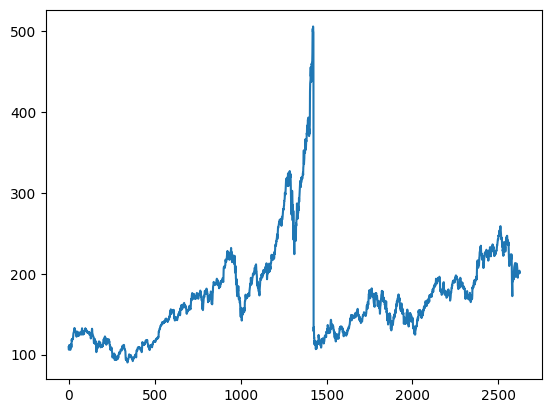

In [15]:
import matplotlib.pyplot as plt
plt.plot(df1)

##### **LSTM are sensitive to the scale of the data, so we apply MinMax scaler**

In [16]:
import numpy as np

In [17]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
df1=scaler.fit_transform(np.array(df1).reshape(-1,1))

In [18]:
print(df1)

[[0.04567649]
 [0.03826819]
 [0.03829224]
 ...
 [0.26527962]
 [0.27319302]
 [0.26725195]]


In [19]:
##splitting dataset into train and test split
training_size=int(len(df1)*0.65)
test_size=len(df1)-training_size
train_data,test_data=df1[0:training_size,:],df1[training_size:len(df1),:1]

In [20]:
training_size,test_size

(1705, 919)

In [22]:
train_data

array([[0.04567649],
       [0.03826819],
       [0.03829224],
       ...,
       [0.12425737],
       [0.12736019],
       [0.12642213]])

In [24]:
import numpy
# convert an array of values into a dataset matrix
def create_dataset(dataset, time_step=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-time_step-1):
		a = dataset[i:(i+time_step), 0]   ###i=0, 0,1,2,3-----99   100
		dataX.append(a)
		dataY.append(dataset[i + time_step, 0])
	return numpy.array(dataX), numpy.array(dataY)

In [25]:
# reshape into X=t,t+1,t+2,t+3 and Y=t+4
time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, ytest = create_dataset(test_data, time_step)

In [29]:
print(X_train)

[[[0.04567649]
  [0.03826819]
  [0.03829224]
  ...
  [0.10150331]
  [0.09447986]
  [0.10031269]]

 [[0.03826819]
  [0.03829224]
  [0.04187613]
  ...
  [0.09447986]
  [0.10031269]
  [0.09967529]]

 [[0.03829224]
  [0.04187613]
  [0.05183403]
  ...
  [0.10031269]
  [0.09967529]
  [0.09606735]]

 ...

 [[0.08329525]
  [0.08926037]
  [0.08642213]
  ...
  [0.12305472]
  [0.12582081]
  [0.11737823]]

 [[0.08926037]
  [0.08642213]
  [0.08300661]
  ...
  [0.12582081]
  [0.11737823]
  [0.12211666]]

 [[0.08642213]
  [0.08300661]
  [0.08262177]
  ...
  [0.11737823]
  [0.12211666]
  [0.12425737]]]


In [30]:
print(X_train.shape), print(y_train.shape)

(1604, 100, 1)
(1604,)


(None, None)

In [31]:
print(X_test.shape), print(ytest.shape)

(818, 100, 1)
(818,)


(None, None)

In [32]:
# reshape input to be [samples, time steps, features] which is required for LSTM
X_train =X_train.reshape(X_train.shape[0],X_train.shape[1] , 1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1] , 1)

In [33]:
### Create the Stacked LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

In [34]:
model=Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(100,1)))
model.add(LSTM(50,return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error',optimizer='adam')
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.fit(X_train,y_train,validation_data=(X_test,ytest),epochs=100,batch_size=64,verbose=1)

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 250ms/step - loss: 0.0250 - val_loss: 6.8663e-04
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 206ms/step - loss: 0.0037 - val_loss: 4.1437e-04
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 258ms/step - loss: 0.0024 - val_loss: 0.0010
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 332ms/step - loss: 0.0031 - val_loss: 3.8829e-04
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 205ms/step - loss: 0.0021 - val_loss: 5.0051e-04
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 210ms/step - loss: 0.0016 - val_loss: 2.7086e-04
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step - loss: 0.0021 - val_loss: 3.9920e-04
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 250ms/step - loss: 0.0028 - val_loss: 3.5197e-04
Epoch 9/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 242ms/step - loss: 0.0015 - val_loss: 4.9669e-04
Epoch 10/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 184ms/step - loss: 8.4766e-04 - val_loss: 2.8468e-04
Epoch 11/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 205ms/step - loss: 0.0012 - val_loss: 2.

In [36]:
import tensorflow as tf
tf.__version__

'2.18.0'

In [37]:
### Lets Do the prediction and check performance metrics
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


In [38]:
##Transformback to original form
train_predict=scaler.inverse_transform(train_predict)
test_predict=scaler.inverse_transform(test_predict)

In [39]:
### Calculate RMSE performance metrics
import math
from sklearn.metrics import mean_squared_error
math.sqrt(mean_squared_error(y_train,train_predict))

175.1263704621057

In [40]:
### Test Data RMSE
math.sqrt(mean_squared_error(ytest,test_predict))

179.91372195099535

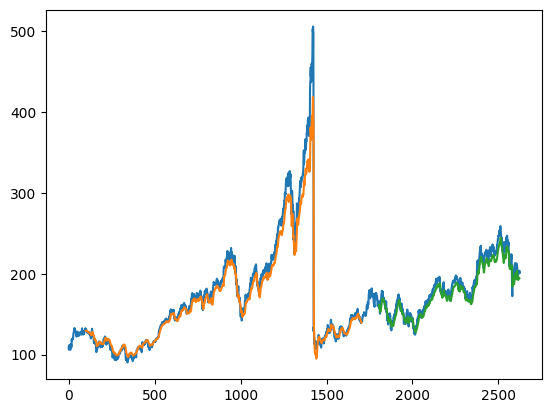

In [41]:
### Plotting
# shift train predictions for plotting
look_back=100
trainPredictPlot = numpy.empty_like(df1)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
# shift test predictions for plotting
testPredictPlot = numpy.empty_like(df1)
testPredictPlot[:, :] = numpy.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(df1)-1, :] = test_predict
# plot baseline and predictions
plt.plot(scaler.inverse_transform(df1))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

In [42]:
len(test_data)

919

In [43]:
x_input=test_data[819:].reshape(1,-1)
x_input.shape

(1, 100)

In [44]:
temp_input=list(x_input)
temp_input=temp_input[0].tolist()

In [ ]:
temp_input

In [45]:
# demonstrate prediction for next 10 days
from numpy import array

lst_output=[]
n_steps=100
i=0
while(i<30):

    if(len(temp_input)>100):
        #print(temp_input)
        x_input=np.array(temp_input[1:])
        print("{} day input {}".format(i,x_input))
        x_input=x_input.reshape(1,-1)
        x_input = x_input.reshape((1, n_steps, 1))
        #print(x_input)
        yhat = model.predict(x_input, verbose=0)
        print("{} day output {}".format(i,yhat))
        temp_input.extend(yhat[0].tolist())
        temp_input=temp_input[1:]
        #print(temp_input)
        lst_output.extend(yhat.tolist())
        i=i+1
    else:
        x_input = x_input.reshape((1, n_steps,1))
        yhat = model.predict(x_input, verbose=0)
        print(yhat[0])
        temp_input.extend(yhat[0].tolist())
        print(len(temp_input))
        lst_output.extend(yhat.tolist())
        i=i+1


print(lst_output)

[0.2502969]
101
1 day input [0.33173782 0.33587492 0.31822008 0.32108238 0.32067348 0.31855683
 0.33558629 0.35579074 0.35843656 0.35417919 0.35035478 0.3311365
 0.34265785 0.3418641  0.34366807 0.33022249 0.3302706  0.34222489
 0.35244738 0.36365604 0.37104029 0.3707276  0.37168972 0.3739988
 0.37332532 0.37705352 0.3769092  0.36084185 0.35348166 0.36440168
 0.35523752 0.35018641 0.3497294  0.34874324 0.35773903 0.3298617
 0.31389056 0.30460613 0.2870475  0.29621167 0.29743836 0.29428743
 0.30042093 0.29767889 0.30770896 0.31362598 0.32088996 0.31555021
 0.32113049 0.306819   0.31699339 0.31954299 0.3212267  0.27143716
 0.23581479 0.21917017 0.19742634 0.2609982  0.24072159 0.25931449
 0.26982562 0.26891161 0.24998196 0.2565003  0.24731209 0.26313891
 0.27482862 0.28389657 0.28608539 0.28815394 0.2907276  0.29383043
 0.29580277 0.27663259 0.26109441 0.2601804  0.25474444 0.257727
 0.2602285  0.28971738 0.2948647  0.29342153 0.29130487 0.29084787
 0.28488274 0.28026458 0.26879134 0.267

In [46]:
day_new=np.arange(1,101)
day_pred=np.arange(101,131)   # Becuse of next 30days prediction

In [48]:
import matplotlib.pyplot as plt

In [49]:
len(df1)

2624

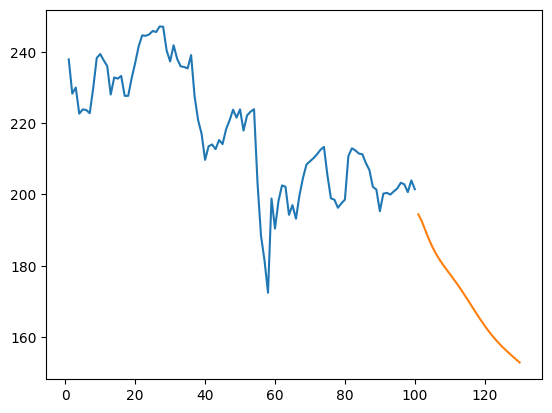

In [50]:
plt.plot(day_new,scaler.inverse_transform(df1[2524:]))
plt.plot(day_pred,scaler.inverse_transform(lst_output))

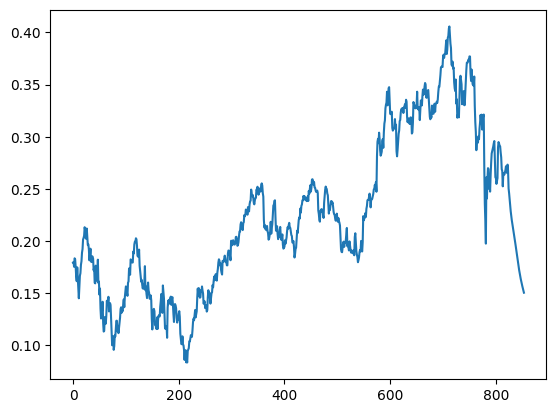

In [52]:
df3=df1.tolist()
df3.extend(lst_output)
plt.plot(df3[1800:])

In [53]:
df3=scaler.inverse_transform(df3).tolist()

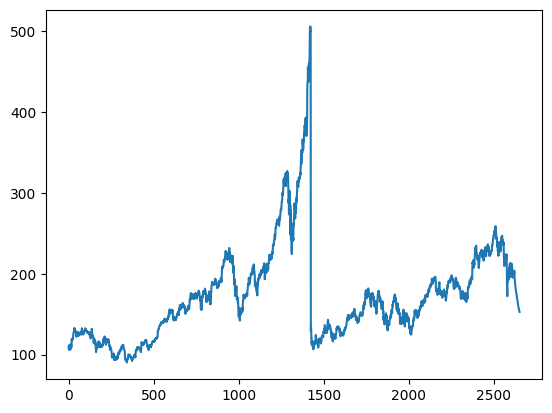

In [54]:
plt.plot(df3)